# Qdrant 설치 확인 

## Qdrant 클라이언트 연결 테스트 

In [1]:
from qdrant_client import QdrantClient

client = QdrantClient(host="localhost", port=6333)

# Qdrant Cloud 연결
# client = QdrantClient(
#     url="https://your-cluster.qdrant.io",
#     api_key="your-api-key"
# )

print("Qdrant 클라이언트 연결 완료")

Qdrant 클라이언트 연결 완료


## Qdrant 접속 
```url
http://localhost:6333/dashboard#/welcome
```

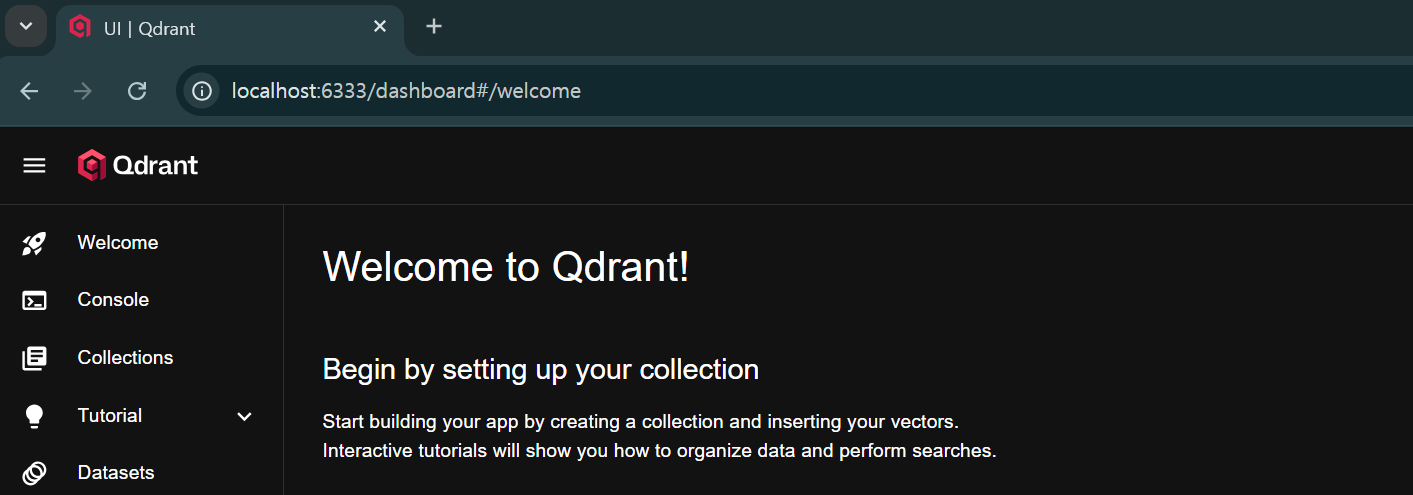

# VectorDB에 데이터 추가하기 

## Loader

In [2]:
from langchain_community.document_loaders import TextLoader

file_path = "./data/rag-keywords.txt"
loader = TextLoader(file_path, encoding='utf-8')


In [3]:
docs = loader.load()
print(f"로드된 파일의 수: {len(docs)}")

로드된 파일의 수: 1


## Splitter

In [4]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=300, chunk_overlap=30)
    

In [5]:
docs_by_splitter = text_splitter.split_documents(docs)
print(f"분리된 문서의 수: {len(docs_by_splitter)}")

분리된 문서의 수: 30


## Embedding Model

### API Key 등록 
- [OpenAI Key 발급](https://platform.openai.com/api-keys)
- [Huggingface 토큰 등록](https://huggingface.co/settings/tokens)

In [6]:
from dotenv import load_dotenv 

load_dotenv()

True

In [7]:
from langchain_openai import OpenAIEmbeddings

embeddings_model = OpenAIEmbeddings(model="text-embedding-3-small")

## Qdrant VectorStore

In [8]:
from langchain_qdrant import QdrantVectorStore

# Qdrant 벡터스토어 생성
vectorstore = QdrantVectorStore.from_documents(
    documents=docs_by_splitter,           # 분할된 문서
    embedding=embeddings_model,       # 임베딩 함수
    location="http://localhost:6333",        # 또는 인메모리 모드(":memory:")
    collection_name="rag_keywords",  # 컬렉션 이름
)

print("Qdrant 벡터스토어 생성 완료")

Qdrant 벡터스토어 생성 완료


### 저장된 데이터 확인

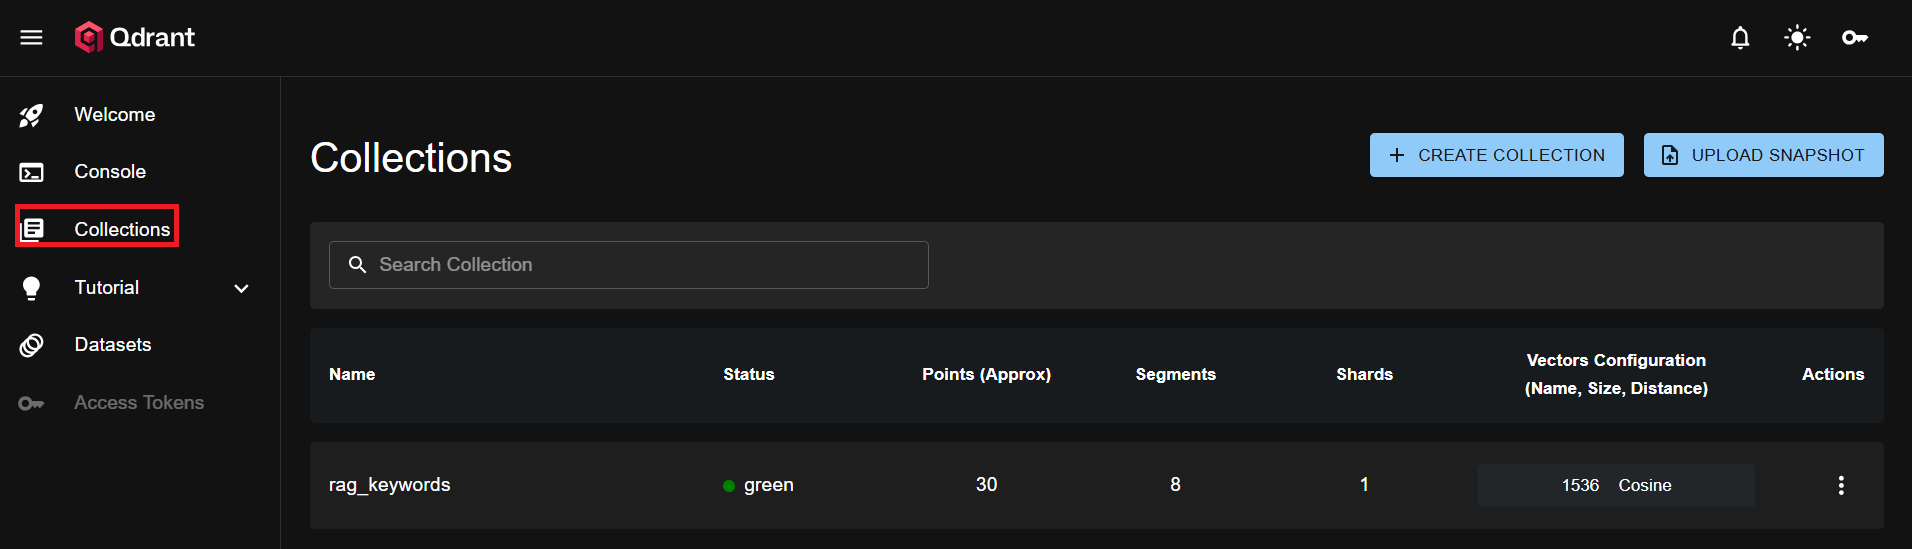

### 조회 테스트

In [9]:
results = vectorstore.similarity_search("TF IDF 에 대하여 알려줘", k=3)

for i, doc in enumerate(results, 1):
    print(f"{i}. {doc.page_content}")
    print(f"   메타데이터: {doc.metadata}")
    print()

1. 정의: TF-IDF는 문서 내에서 단어의 중요도를 평가하는 데 사용되는 통계적 척도입니다. 이는 문서 내 단어의 빈도와 전체 문서 집합에서 그 단어의 희소성을 고려합니다.
예시: 많은 문서에서 자주 등장하지 않는 단어는 높은 TF-IDF 값을 가집니다.
연관키워드: 자연어 처리, 정보 검색, 데이터 마이닝

Deep Learning
   메타데이터: {'source': './data/rag-keywords.txt', '_id': 'd68cdab2-3e59-48de-a864-6985fa57e7b5', '_collection_name': 'rag_keywords'}

2. JSON

정의: JSON(JavaScript Object Notation)은 경량의 데이터 교환 형식으로, 사람과 기계 모두에게 읽기 쉬운 텍스트를 사용하여 데이터 객체를 표현합니다.
예시: {"이름": "홍길동", "나이": 30, "직업": "개발자"}는 JSON 형식의 데이터입니다.
연관키워드: 데이터 교환, 웹 개발, API

Transformer
   메타데이터: {'source': './data/rag-keywords.txt', '_id': '68936fbf-a87d-4582-8bbc-20aed525a2e0', '_collection_name': 'rag_keywords'}

3. DataFrame

정의: DataFrame은 행과 열로 이루어진 테이블 형태의 데이터 구조로, 주로 데이터 분석 및 처리에 사용됩니다.
예시: 판다스 라이브러리에서 DataFrame은 다양한 데이터 타입의 열을 가질 수 있으며, 데이터 조작과 분석을 용이하게 합니다.
연관키워드: 데이터 분석, 판다스, 데이터 처리

Attention 메커니즘
   메타데이터: {'source': './data/rag-keywords.txt', '_id': '94cb5043-5b72-4877-b733-806c1e355de0', '_collection_name': 'rag_keywords'}

